# Clustering — Pure PySpark
### K-Means + Gaussian Mixture Model on Wheat Seeds Dataset
**Dataset:** `seed.txt` | 210 samples | 7 features | 3 wheat varieties

## Step 0 — Spark Setup

In [1]:

import os
import urllib.request
import ssl

data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

data_dir1 = "hadoop/bin"
os.makedirs(data_dir1, exist_ok=True)

urls_and_paths = {
    "https://raw.githubusercontent.com/Yadav-Raj-Ghimire/BigData_work/refs/heads/main/spark-config/test.txt": os.path.join(data_dir, "test.txt"),
    "https://github.com/Yadav-Raj-Ghimire/BigData_work/tree/main/spark-config/hadoop/bin/winutils.exe": os.path.join(data_dir1, "winutils.exe"),
    "https://github.com/Yadav-Raj-Ghimire/BigData_work/tree/main/spark-config/hadoop/bin/hadoop.dll": os.path.join(data_dir1, "hadoop.dll")
}


# Create an unverified SSL context
ssl_context = ssl._create_unverified_context()

for url, path in urls_and_paths.items():
    # Use the unverified context with urlopen
    with urllib.request.urlopen(url, context=ssl_context) as response, open(path, 'wb') as out_file:
        data = response.read()
        out_file.write(data)
import os, urllib.request, ssl; ssl_context = ssl._create_unverified_context(); [open(path, 'wb').write(urllib.request.urlopen(url, context=ssl_context).read())]


# ======================================================================================

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, LinearSVC, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.ml.linalg import Vectors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys

from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType
from pyspark.ml.feature      import VectorAssembler, StandardScaler
from pyspark.ml.clustering   import KMeans, GaussianMixture
from pyspark.ml.evaluation   import ClusteringEvaluator
from pyspark.ml              import Pipeline

python_path = sys.executable
os.environ['PYSPARK_PYTHON'] = python_path
os.environ['HADOOP_HOME'] ="hadoop"
os.environ['JAVA_HOME'] = r'C:\Users\yrghimire\.jdks\corretto-1.8.0_482'
######################🔴🔴🔴################################

#os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages com.datastax.spark:spark-cassandra-connector_2.12:3.5.1 pyspark-shell'
#os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-avro_2.12:3.5.4 pyspark-shell'
#os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.4 pyspark-shell'


conf = SparkConf().setAppName("BigData Assignment 1").setMaster("local[*]").set("spark.driver.host","localhost").set("spark.default.parallelism", "4").set("spark.sql.codegen.wholeStage","false").set("spark.sql.codegen.maxFields","200").set("spark.driver.memory","32g").set("spark.driver.maxResultSize","8g")

sc = SparkContext(conf=conf)

spark = SparkSession.builder.getOrCreate()

spark.read.format("csv").load("data/test.txt").toDF("Success").show(20, False)


##################🔴🔴🔴🔴🔴🔴 -> DONT TOUCH ABOVE CODE -- TYPE BELOW ####################################

print()


+---------------------+
|Success              |
+---------------------+
|Spark Journey Started|
+---------------------+




## Step 1 — Load seed.txt into Spark DataFrame

In [3]:
# Define explicit schema for all 8 columns
schema = StructType([
    StructField('area',           DoubleType(),  True),
    StructField('perimeter',      DoubleType(),  True),
    StructField('compactness',    DoubleType(),  True),
    StructField('kernel_length',  DoubleType(),  True),
    StructField('kernel_width',   DoubleType(),  True),
    StructField('asymmetry',      DoubleType(),  True),
    StructField('groove_length',  DoubleType(),  True),
    StructField('label',          IntegerType(), True)
])

# Read tab-separated file
df = (spark.read.format('csv')
      .option('header',    'false')
      .option('delimiter', '\t')
      .option('inferSchema', 'false')
      .schema(schema)
      .load('Dataset/seeds_dataset.txt'))

print(f'Rows: {df.count()} | Cols: {len(df.columns)}')
df.printSchema()
df.show(5)

Rows: 210 | Cols: 8
root
 |-- area: double (nullable = true)
 |-- perimeter: double (nullable = true)
 |-- compactness: double (nullable = true)
 |-- kernel_length: double (nullable = true)
 |-- kernel_width: double (nullable = true)
 |-- asymmetry: double (nullable = true)
 |-- groove_length: double (nullable = true)
 |-- label: integer (nullable = true)

+-----+---------+-----------+-------------+------------+---------+-------------+-----+
| area|perimeter|compactness|kernel_length|kernel_width|asymmetry|groove_length|label|
+-----+---------+-----------+-------------+------------+---------+-------------+-----+
|15.26|    14.84|      0.871|        5.763|       3.312|    2.221|         5.22|    1|
|14.88|    14.57|     0.8811|        5.554|       3.333|    1.018|        4.956|    1|
|14.29|    14.09|      0.905|        5.291|       3.337|    2.699|        4.825|    1|
|13.84|    13.94|     0.8955|        5.324|       3.379|    2.259|        4.805|    1|
|16.14|    14.99|     0.9034|   

## Step 2 — Explore Data with Pure Spark

In [4]:
# Class distribution (3 wheat varieties)
print('Class distribution (1=Kama, 2=Rosa, 3=Canadian):')
df.groupBy('label').count().orderBy('label').show()

# Feature statistics using Spark describe()
feature_cols = ['area','perimeter','compactness','kernel_length',
                'kernel_width','asymmetry','groove_length']
print('Feature Statistics:')
df.select(feature_cols).describe().show(truncate=False)

Class distribution (1=Kama, 2=Rosa, 3=Canadian):
+-----+-----+
|label|count|
+-----+-----+
| NULL|   10|
|    1|   66|
|    2|   68|
|    3|   65|
|    5|    1|
+-----+-----+

Feature Statistics:
+-------+------------------+------------------+--------------------+------------------+------------------+------------------+------------------+
|summary|area              |perimeter         |compactness         |kernel_length     |kernel_width      |asymmetry         |groove_length     |
+-------+------------------+------------------+--------------------+------------------+------------------+------------------+------------------+
|count  |210               |210               |207                 |210               |209               |210               |206               |
|mean   |14.847523809523816|14.559285714285718|0.8712797101449273  |5.563918095238097 |3.28144019138756  |3.6935295238095227|5.407529126213591 |
|stddev |2.9096994306873647|1.3059587265640225|0.023305838551641696|0.719593612

## Step 3 — Feature Engineering: VectorAssembler → StandardScaler

In [5]:
# Step 1: Assemble 7 feature columns into a single vector
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='raw_features',
    handleInvalid='skip'
)

# Step 2: StandardScaler — zero mean, unit variance
scaler = StandardScaler(
    inputCol='raw_features',
    outputCol='features',
    withMean=True,
    withStd=True
)

# Build and fit preprocessing pipeline
prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model    = prep_pipeline.fit(df)
scaled_df     = prep_model.transform(df).select('features', 'label')

print('Scaled DataFrame:')
scaled_df.show(5, truncate=True)
print('✅ Features assembled and scaled')

Scaled DataFrame:
+--------------------+-----+
|            features|label|
+--------------------+-----+
|[0.12106684502950...|    1|
|[-0.0090766391619...|    1|
|[-0.2111415225117...|    1|
|[-0.3652588064226...|    1|
|[0.42245175578857...|    1|
+--------------------+-----+
only showing top 5 rows

✅ Features assembled and scaled


## Step 4 — K-Means: Find Best K using Elbow Method (K = 2 to 8)

  K=2  |  Silhouette=0.6699  |  WSSSE=626.54
  K=3  |  Silhouette=0.5926  |  WSSSE=413.24
  K=4  |  Silhouette=0.4832  |  WSSSE=369.66
  K=5  |  Silhouette=0.3939  |  WSSSE=325.64
  K=6  |  Silhouette=0.3651  |  WSSSE=291.69
  K=7  |  Silhouette=0.3749  |  WSSSE=264.98
  K=8  |  Silhouette=0.4247  |  WSSSE=235.43


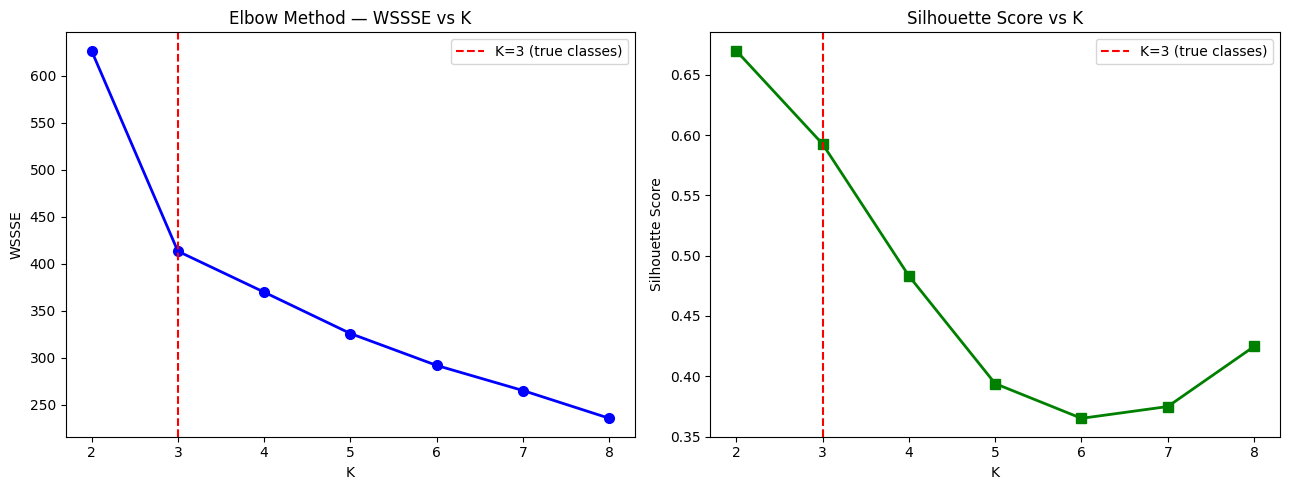

In [9]:
evaluator = ClusteringEvaluator(
    featuresCol='features',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean'
)

k_values    = list(range(2, 9))
silhouettes = []
wssse_list  = []

_round = __builtins__['round'] if isinstance(__builtins__, dict) else __builtins__.round

for k in k_values:
    km    = KMeans(featuresCol='features', k=k, seed=42, maxIter=100)
    model = km.fit(scaled_df)
    preds = model.transform(scaled_df)
    sil   = evaluator.evaluate(preds)
    wssse = model.summary.trainingCost
    silhouettes.append(_round(float(sil),   4))
    wssse_list.append( _round(float(wssse), 4))
    print(f'  K={k}  |  Silhouette={sil:.4f}  |  WSSSE={wssse:.2f}')

# Elbow + Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_values, wssse_list,  'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('K'); axes[0].set_ylabel('WSSSE')
axes[0].set_title('Elbow Method — WSSSE vs K')
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 (true classes)')
axes[0].legend()

axes[1].plot(k_values, silhouettes, 'gs-', linewidth=2, markersize=7)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].axvline(x=3, color='red', linestyle='--', label='K=3 (true classes)')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()


## Step 5 — K-Means with K=3 (Final Model)

In [10]:
# Train final K-Means with K=3
kmeans_final = KMeans(featuresCol='features', k=3, seed=42, maxIter=100)
km_model     = kmeans_final.fit(scaled_df)
km_preds     = km_model.transform(scaled_df)

# Silhouette score
km_sil = evaluator.evaluate(km_preds)

print('='*50)
print('  K-MEANS (K=3) RESULTS')
print('='*50)
print(f'  Silhouette Score : {km_sil:.4f}')
print(f'  WSSSE            : {km_model.summary.trainingCost:.4f}')
print()
print('Cluster sizes:')
km_preds.groupBy('prediction').count().orderBy('prediction').show()

print('Cluster vs True Label cross-tab:')
km_preds.groupBy('prediction','label').count().orderBy('prediction','label').show()

  K-MEANS (K=3) RESULTS
  Silhouette Score : 0.5926
  WSSSE            : 413.2426

Cluster sizes:
+----------+-----+
|prediction|count|
+----------+-----+
|         0|   69|
|         1|   67|
|         2|   67|
+----------+-----+

Cluster vs True Label cross-tab:
+----------+-----+-----+
|prediction|label|count|
+----------+-----+-----+
|         0| NULL|    2|
|         0|    1|    5|
|         0|    3|   62|
|         1| NULL|    1|
|         1|    1|    2|
|         1|    2|   64|
|         2| NULL|    1|
|         2|    1|   59|
|         2|    2|    4|
|         2|    3|    3|
+----------+-----+-----+



## Step 6 — K-Means Cluster Centers

In [11]:
from pyspark.sql.types import StringType

centers = km_model.clusterCenters()
print('K-Means Cluster Centers (in scaled space):')
print(f'{"Feature":<18}', end='')
[print(f'  Cluster {i}', end='') for i in range(3)]
print()
print('-'*55)
for i, feat in enumerate(feature_cols):
    vals = ''.join([f'  {c[i]:>9.4f}' for c in centers])
    print(f'{feat:<18}{vals}')

# Per-cluster feature averages using Spark SQL
print('\nPer-cluster feature means (original scale):')
km_preds_full = km_model.transform(
    prep_model.transform(df)   # keep all original cols
)
km_preds_full.groupBy('prediction').agg(
    F.round(F.avg('area'),          3).alias('avg_area'),
    F.round(F.avg('perimeter'),     3).alias('avg_perimeter'),
    F.round(F.avg('compactness'),   3).alias('avg_compactness'),
    F.round(F.avg('kernel_length'), 3).alias('avg_kern_len'),
    F.round(F.avg('kernel_width'),  3).alias('avg_kern_wid'),
    F.round(F.avg('asymmetry'),     3).alias('avg_asymmetry'),
    F.round(F.avg('groove_length'), 3).alias('avg_groove')
).orderBy('prediction').show(truncate=False)

K-Means Cluster Centers (in scaled space):
Feature             Cluster 0  Cluster 1  Cluster 2
-------------------------------------------------------
area                  -1.0350     1.2291    -0.1632
perimeter             -1.0140     1.2327    -0.1885
compactness           -0.9583     0.5691     0.4178
kernel_length         -0.9121     1.2070    -0.2677
kernel_width          -1.0852     1.1448    -0.0272
asymmetry              0.6982    -0.0519    -0.6671
groove_length         -0.6323     1.2622    -0.6111

Per-cluster feature means (original scale):
+----------+--------+-------------+---------------+------------+------------+-------------+----------+
|prediction|avg_area|avg_perimeter|avg_compactness|avg_kern_len|avg_kern_wid|avg_asymmetry|avg_groove|
+----------+--------+-------------+---------------+------------+------------+-------------+----------+
|0         |11.884  |13.261       |0.849          |5.236       |2.854       |4.761        |5.108     |
|1         |18.495  |16.203 

## Step 7 — Gaussian Mixture Model (GMM) with K=3

In [12]:
# Train GMM with 3 components
gmm       = GaussianMixture(featuresCol='features', k=3, seed=42, maxIter=100)
gmm_model = gmm.fit(scaled_df)
gmm_preds = gmm_model.transform(scaled_df)

# Silhouette
gmm_sil = evaluator.evaluate(gmm_preds)

print('='*50)
print('  GAUSSIAN MIXTURE MODEL (K=3) RESULTS')
print('='*50)
print(f'  Silhouette Score : {gmm_sil:.4f}')
print(f'  Log-Likelihood   : {gmm_model.summary.logLikelihood:.4f}')
print()
print('GMM cluster sizes:')
gmm_preds.groupBy('prediction').count().orderBy('prediction').show()

print('GMM cluster weights (mixing coefficients):')
for i, w in enumerate(gmm_model.weights):
    print(f'  Component {i}: weight = {w:.4f}')

print('\nGMM Cluster vs True Label cross-tab:')
gmm_preds.groupBy('prediction','label').count().orderBy('prediction','label').show()

  GAUSSIAN MIXTURE MODEL (K=3) RESULTS
  Silhouette Score : 0.3388
  Log-Likelihood   : 205.3069

GMM cluster sizes:
+----------+-----+
|prediction|count|
+----------+-----+
|         0|   97|
|         1|   80|
|         2|   26|
+----------+-----+

GMM cluster weights (mixing coefficients):
  Component 0: weight = 0.4764
  Component 1: weight = 0.3957
  Component 2: weight = 0.1279

GMM Cluster vs True Label cross-tab:
+----------+-----+-----+
|prediction|label|count|
+----------+-----+-----+
|         0| NULL|    3|
|         0|    1|   33|
|         0|    3|   61|
|         1| NULL|    1|
|         1|    1|   15|
|         1|    2|   64|
|         2|    1|   18|
|         2|    2|    4|
|         2|    3|    4|
+----------+-----+-----+



## Step 8 — GMM: Gaussian Component Parameters

In [13]:
print('GMM Gaussian Component Means (scaled space):')
print(f'{"Feature":<18}', end='')
[print(f'  Comp {i}  ', end='') for i in range(3)]
print()
print('-'*55)
for i, feat in enumerate(feature_cols):
    vals = ''.join([f'  {gmm_model.gaussians[c].mean[i]:>9.4f}' for c in range(3)])
    print(f'{feat:<18}{vals}')

GMM Gaussian Component Means (scaled space):
Feature             Comp 0    Comp 1    Comp 2  
-------------------------------------------------------
area                  -0.8422     1.0684    -0.1683
perimeter             -0.8465     1.0633    -0.1363
compactness           -0.5155     0.6169     0.0117
kernel_length         -0.8011     1.0053    -0.1261
kernel_width          -0.8387     1.0332    -0.0723
asymmetry              0.2428    -0.1865    -0.3274
groove_length         -0.7164     0.9657    -0.3189


## Step 9 — Compare K-Means vs GMM

In [18]:
# Store values first as plain Python floats (avoid Spark round conflict)
km_sil_val   = float(f"{km_sil:.4f}")
km_cost_val  = float(f"{km_model.summary.trainingCost:.4f}")
gmm_sil_val  = float(f"{gmm_sil:.4f}")
gmm_ll_val   = float(f"{gmm_model.summary.logLikelihood:.4f}")

# Build comparison DataFrame in pure Spark
comparison_rdd = sc.parallelize([
    ('K-Means', 3, km_sil_val,  km_cost_val, 'Hard'),
    ('GMM',     3, gmm_sil_val, gmm_ll_val,  'Soft')
])

cmp_schema = StructType([
    StructField('Model',      StringType(),  True),
    StructField('K',          IntegerType(), True),
    StructField('Silhouette', DoubleType(),  True),
    StructField('Cost_or_LL', DoubleType(),  True),
    StructField('Assignment', StringType(),  True)
])

cmp_df = spark.createDataFrame(comparison_rdd, schema=cmp_schema)

print('='*60)
print('   K-MEANS  vs  GMM  —  COMPARISON')
print('='*60)
cmp_df.show(truncate=False)

   K-MEANS  vs  GMM  —  COMPARISON
+-------+---+----------+----------+----------+
|Model  |K  |Silhouette|Cost_or_LL|Assignment|
+-------+---+----------+----------+----------+
|K-Means|3  |0.5926    |413.2426  |Hard      |
|GMM    |3  |0.3388    |205.3069  |Soft      |
+-------+---+----------+----------+----------+



## Step 10 — Visualisation: Scatter Plot (Area vs Perimeter coloured by cluster)

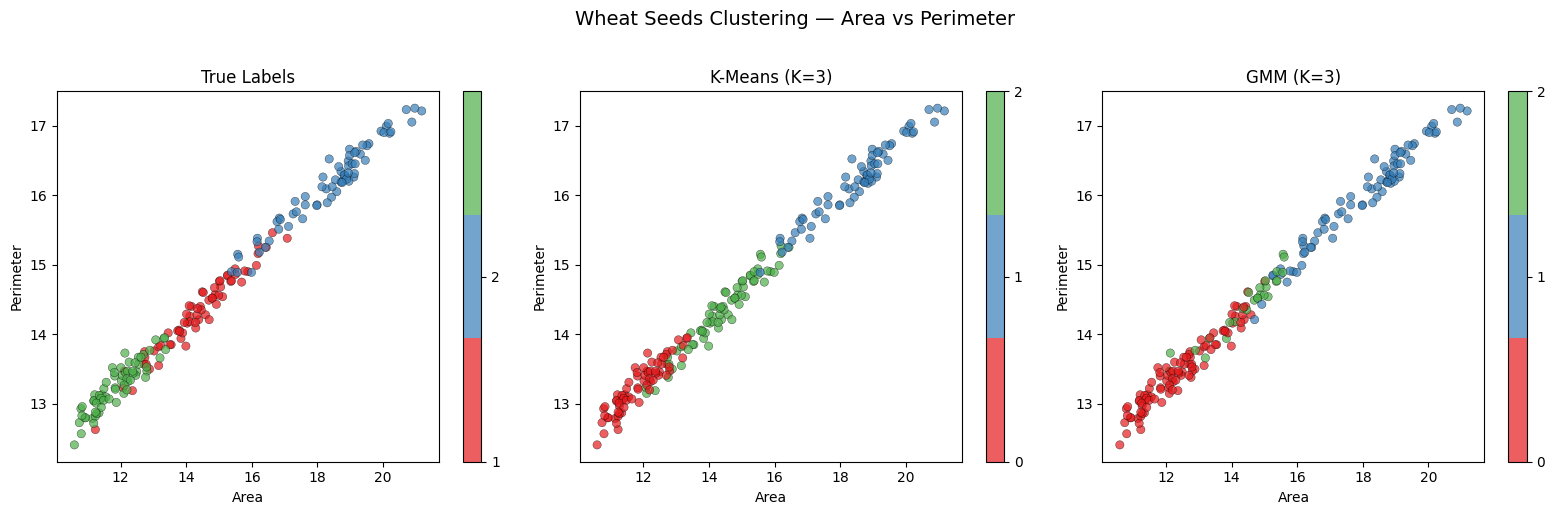

✅ Plot saved to clustering_results.png


In [20]:
# Collect only the 3 small columns needed for plotting
import matplotlib

km_plot  = km_preds_full.select('area','perimeter','prediction','label').collect()
gmm_full = gmm_model.transform(prep_model.transform(df))
gm_plot  = gmm_full.select('area','perimeter','prediction','label').collect()

def unpack(rows, x_col, y_col, pred_col):
    return ([r[x_col] for r in rows],
            [r[y_col] for r in rows],
            [r[pred_col] for r in rows])

km_x, km_y, km_c = unpack(km_plot,  'area', 'perimeter', 'prediction')
gm_x, gm_y, gm_c = unpack(gm_plot,  'area', 'perimeter', 'prediction')
tr_x, tr_y, tr_c = unpack(km_plot,  'area', 'perimeter', 'label')

colors = ['#e41a1c', '#377eb8', '#4daf4a']
cmap   = matplotlib.colors.ListedColormap(colors)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, xs, ys, cs, title in zip(
        axes,
        [tr_x,  km_x,  gm_x],
        [tr_y,  km_y,  gm_y],
        [tr_c,  km_c,  gm_c],
        ['True Labels', 'K-Means (K=3)', 'GMM (K=3)']):
    sc_plot = ax.scatter(xs, ys, c=cs, cmap=cmap, alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.set_xlabel('Area'); ax.set_ylabel('Perimeter')
    ax.set_title(title)
    plt.colorbar(sc_plot, ax=ax, ticks=[0,1,2])

plt.suptitle('Wheat Seeds Clustering — Area vs Perimeter', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to clustering_results.png')

## Step 11 — Silhouette Bar Chart

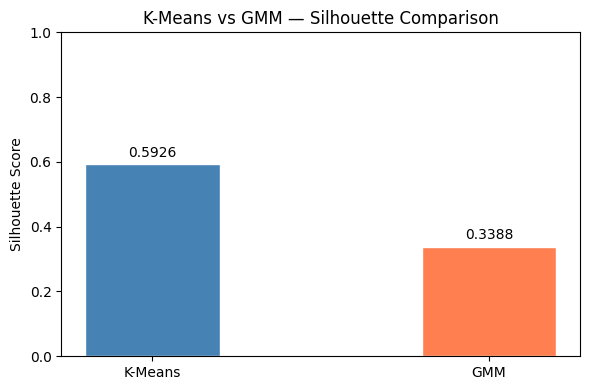

In [21]:
models = ['K-Means', 'GMM']
scores = [km_sil,   gmm_sil]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, scores, color=['steelblue','coral'], edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1)
ax.set_ylabel('Silhouette Score')
ax.set_title('K-Means vs GMM — Silhouette Comparison')
plt.tight_layout()
plt.savefig('silhouette_comparison.png', dpi=150)
plt.show()

## Step 12 — Final Summary & Stop Spark

In [22]:
# All stats via Spark SQL
km_preds_full.createOrReplaceTempView('km_results')

print('='*60)
print('  FINAL SUMMARY — Wheat Seeds Clustering')
print('='*60)
print('  Dataset  : 210 samples | 7 features | 3 true classes')
print()
print('  K-MEANS (K=3):')
print(f'    Silhouette Score : {km_sil:.4f}')
print(f'    WSSSE            : {km_model.summary.trainingCost:.4f}')
print()
print('  GMM (K=3):')
print(f'    Silhouette Score : {gmm_sil:.4f}')
print(f'    Log-Likelihood   : {gmm_model.summary.logLikelihood:.4f}')
print()
winner = 'K-Means' if km_sil >= gmm_sil else 'GMM'
print(f'  🏆 Better Silhouette: {winner}')
print('='*60)

sc.stop()
print('\n✅ Spark stopped. All done!')

  FINAL SUMMARY — Wheat Seeds Clustering
  Dataset  : 210 samples | 7 features | 3 true classes

  K-MEANS (K=3):
    Silhouette Score : 0.5926
    WSSSE            : 413.2426

  GMM (K=3):
    Silhouette Score : 0.3388
    Log-Likelihood   : 205.3069

  🏆 Better Silhouette: K-Means

✅ Spark stopped. All done!
